In [1]:
from sklearn.metrics import roc_auc_score
import lightgbm as lgbm
import optuna
import pandas as pd
import joblib

In [2]:
from sklearn.metrics import fbeta_score

In [3]:
X_train = pd.read_parquet('../data/X_train.parquet')
X_val = pd.read_parquet('../data/X_val.parquet')
X_test = pd.read_parquet('../data/X_test.parquet')

y_train = pd.read_parquet('../data/y_train.parquet').squeeze()
y_val = pd.read_parquet('../data/y_val.parquet').squeeze()
y_test = pd.read_parquet('../data/y_test.parquet').squeeze()

### 1. Hyperparameter Tuning

In [20]:
def objective(trial):
    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "verbose": -1,
        "n_jobs": -1,
        
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.09),
        "num_leaves": trial.suggest_int("num_leaves", 150, 350),
        "max_depth": trial.suggest_int("max_depth", 10, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 150),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
        "n_estimators": 4000
    }
    
    threshold = trial.suggest_float("threshold", 0.3, 0.6)
    
    model = lgbm.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgbm.early_stopping(stopping_rounds=50), lgbm.log_evaluation(100)]
    )
    y_val_delay_probabilities = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_delay_probabilities >= threshold).astype(int)
    score = fbeta_score(y_val, y_val_pred, beta=0.5, average='binary')
    return score

In [21]:
study = optuna.create_study(direction="maximize")

[I 2026-07-01 14:09:53,980] A new study created in memory with name: no-name-ec314ec0-2118-43da-b389-51037a15f0e1


In [24]:
print(f"Completed trials: {len(study.trials)}")
print(f"Best value so far: {study.best_value}")

Completed trials: 10
Best value so far: 0.4793910482614946


In [25]:
study.optimize(objective, n_trials=10)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.721751	valid_0's binary_logloss: 0.457963
[200]	valid_0's auc: 0.727781	valid_0's binary_logloss: 0.454503
[300]	valid_0's auc: 0.73074	valid_0's binary_logloss: 0.452662
[400]	valid_0's auc: 0.732924	valid_0's binary_logloss: 0.451297
[500]	valid_0's auc: 0.734579	valid_0's binary_logloss: 0.450303
[600]	valid_0's auc: 0.736025	valid_0's binary_logloss: 0.449416
[700]	valid_0's auc: 0.736994	valid_0's binary_logloss: 0.448773
[800]	valid_0's auc: 0.737752	valid_0's binary_logloss: 0.448281
[900]	valid_0's auc: 0.738485	valid_0's binary_logloss: 0.447768
[1000]	valid_0's auc: 0.739341	valid_0's binary_logloss: 0.447219
[1100]	valid_0's auc: 0.740075	valid_0's binary_logloss: 0.446751
[1200]	valid_0's auc: 0.740687	valid_0's binary_logloss: 0.446337
[1300]	valid_0's auc: 0.741147	valid_0's binary_logloss: 0.446013
[1400]	valid_0's auc: 0.741658	valid_0's binary_logloss: 0.445657
[1500]	valid_0's auc: 0.7

[I 2026-07-01 15:36:23,884] Trial 10 finished with value: 0.4752291373075957 and parameters: {'learning_rate': 0.08754466401727987, 'num_leaves': 153, 'max_depth': 12, 'min_child_samples': 85, 'reg_alpha': 0.26401349188627476, 'reg_lambda': 0.7281059136698155, 'threshold': 0.3929112486225095}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.722365	valid_0's binary_logloss: 0.457685
[200]	valid_0's auc: 0.729589	valid_0's binary_logloss: 0.45344
[300]	valid_0's auc: 0.733016	valid_0's binary_logloss: 0.451364
[400]	valid_0's auc: 0.73512	valid_0's binary_logloss: 0.450027
[500]	valid_0's auc: 0.736562	valid_0's binary_logloss: 0.449114
[600]	valid_0's auc: 0.737901	valid_0's binary_logloss: 0.448232
[700]	valid_0's auc: 0.739064	valid_0's binary_logloss: 0.447485
[800]	valid_0's auc: 0.739919	valid_0's binary_logloss: 0.446902
[900]	valid_0's auc: 0.740851	valid_0's binary_logloss: 0.446283
[1000]	valid_0's auc: 0.741532	valid_0's binary_logloss: 0.445826
[1100]	valid_0's auc: 0.74211	valid_0's binary_logloss: 0.445439
[1200]	valid_0's auc: 0.74278	valid_0's binary_logloss: 0.444983
[1300]	valid_0's auc: 0.743186	valid_0's binary_logloss: 0.444689
[1400]	valid_0's auc: 0.74361	valid_0's binary_logloss: 0.444404
[1500]	valid_0's auc: 0.74391

[I 2026-07-01 15:45:25,441] Trial 11 finished with value: 0.3955790370947739 and parameters: {'learning_rate': 0.058886319505675744, 'num_leaves': 247, 'max_depth': 15, 'min_child_samples': 142, 'reg_alpha': 0.354885085474542, 'reg_lambda': 0.09000597747835759, 'threshold': 0.5375212490047}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.723825	valid_0's binary_logloss: 0.456861
[200]	valid_0's auc: 0.72956	valid_0's binary_logloss: 0.453506
[300]	valid_0's auc: 0.733037	valid_0's binary_logloss: 0.451386
[400]	valid_0's auc: 0.735084	valid_0's binary_logloss: 0.450112
[500]	valid_0's auc: 0.736803	valid_0's binary_logloss: 0.449023
[600]	valid_0's auc: 0.737786	valid_0's binary_logloss: 0.448367
[700]	valid_0's auc: 0.738909	valid_0's binary_logloss: 0.447592
[800]	valid_0's auc: 0.739776	valid_0's binary_logloss: 0.447034
[900]	valid_0's auc: 0.740688	valid_0's binary_logloss: 0.446431
[1000]	valid_0's auc: 0.741403	valid_0's binary_logloss: 0.445945
[1100]	valid_0's auc: 0.741903	valid_0's binary_logloss: 0.445608
[1200]	valid_0's auc: 0.742535	valid_0's binary_logloss: 0.445179
[1300]	valid_0's auc: 0.74308	valid_0's binary_logloss: 0.444797
[1400]	valid_0's auc: 0.743573	valid_0's binary_logloss: 0.444452
[1500]	valid_0's auc: 0.74

[I 2026-07-01 15:53:43,236] Trial 12 finished with value: 0.47708528295129704 and parameters: {'learning_rate': 0.07431401571865534, 'num_leaves': 330, 'max_depth': 10, 'min_child_samples': 127, 'reg_alpha': 0.9471038266920814, 'reg_lambda': 0.4066161590222581, 'threshold': 0.39137595965181865}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.723612	valid_0's binary_logloss: 0.457012
[200]	valid_0's auc: 0.729359	valid_0's binary_logloss: 0.453619
[300]	valid_0's auc: 0.732621	valid_0's binary_logloss: 0.451643
[400]	valid_0's auc: 0.734901	valid_0's binary_logloss: 0.450221
[500]	valid_0's auc: 0.736665	valid_0's binary_logloss: 0.449093
[600]	valid_0's auc: 0.737891	valid_0's binary_logloss: 0.448273
[700]	valid_0's auc: 0.738919	valid_0's binary_logloss: 0.44759
[800]	valid_0's auc: 0.739733	valid_0's binary_logloss: 0.447075
[900]	valid_0's auc: 0.740527	valid_0's binary_logloss: 0.446539
[1000]	valid_0's auc: 0.741312	valid_0's binary_logloss: 0.446017
[1100]	valid_0's auc: 0.741882	valid_0's binary_logloss: 0.44562
[1200]	valid_0's auc: 0.742416	valid_0's binary_logloss: 0.445249
[1300]	valid_0's auc: 0.742879	valid_0's binary_logloss: 0.444915
[1400]	valid_0's auc: 0.743397	valid_0's binary_logloss: 0.444544
[1500]	valid_0's auc: 0.74

[I 2026-07-01 16:02:00,378] Trial 13 finished with value: 0.47475821470667234 and parameters: {'learning_rate': 0.07178030979340162, 'num_leaves': 349, 'max_depth': 10, 'min_child_samples': 127, 'reg_alpha': 0.9822674462157938, 'reg_lambda': 0.4235395885339536, 'threshold': 0.3995403521322403}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.724474	valid_0's binary_logloss: 0.456424
[200]	valid_0's auc: 0.730658	valid_0's binary_logloss: 0.452791
[300]	valid_0's auc: 0.733786	valid_0's binary_logloss: 0.450856
[400]	valid_0's auc: 0.735885	valid_0's binary_logloss: 0.449526
[500]	valid_0's auc: 0.73745	valid_0's binary_logloss: 0.448522
[600]	valid_0's auc: 0.738661	valid_0's binary_logloss: 0.447747
[700]	valid_0's auc: 0.739672	valid_0's binary_logloss: 0.447033
[800]	valid_0's auc: 0.740556	valid_0's binary_logloss: 0.446452
[900]	valid_0's auc: 0.741365	valid_0's binary_logloss: 0.445903
[1000]	valid_0's auc: 0.742007	valid_0's binary_logloss: 0.445469
[1100]	valid_0's auc: 0.742547	valid_0's binary_logloss: 0.445096
[1200]	valid_0's auc: 0.743128	valid_0's binary_logloss: 0.444693
[1300]	valid_0's auc: 0.743615	valid_0's binary_logloss: 0.444368
[1400]	valid_0's auc: 0.744127	valid_0's binary_logloss: 0.443997
[1500]	valid_0's auc: 0.7

[I 2026-07-01 16:10:19,743] Trial 14 finished with value: 0.479195209107216 and parameters: {'learning_rate': 0.07548417850402073, 'num_leaves': 309, 'max_depth': 11, 'min_child_samples': 113, 'reg_alpha': 0.9694986150924167, 'reg_lambda': 0.38855817887412747, 'threshold': 0.38001911635521085}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.724978	valid_0's binary_logloss: 0.456164
[200]	valid_0's auc: 0.731238	valid_0's binary_logloss: 0.452455
[300]	valid_0's auc: 0.733789	valid_0's binary_logloss: 0.450847
[400]	valid_0's auc: 0.735979	valid_0's binary_logloss: 0.449433
[500]	valid_0's auc: 0.737632	valid_0's binary_logloss: 0.448331
[600]	valid_0's auc: 0.739162	valid_0's binary_logloss: 0.447329
[700]	valid_0's auc: 0.740093	valid_0's binary_logloss: 0.446715
[800]	valid_0's auc: 0.741023	valid_0's binary_logloss: 0.446083
[900]	valid_0's auc: 0.741686	valid_0's binary_logloss: 0.445619
[1000]	valid_0's auc: 0.742265	valid_0's binary_logloss: 0.445223
[1100]	valid_0's auc: 0.742824	valid_0's binary_logloss: 0.444824
[1200]	valid_0's auc: 0.743344	valid_0's binary_logloss: 0.44446
[1300]	valid_0's auc: 0.743774	valid_0's binary_logloss: 0.44416
[1400]	valid_0's auc: 0.744235	valid_0's binary_logloss: 0.443827
[1500]	valid_0's auc: 0.74

[I 2026-07-01 16:17:56,336] Trial 15 finished with value: 0.4770382105665163 and parameters: {'learning_rate': 0.08149073133306012, 'num_leaves': 302, 'max_depth': 11, 'min_child_samples': 111, 'reg_alpha': 0.7579668009341618, 'reg_lambda': 0.4229945517824689, 'threshold': 0.35790751182891223}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.723259	valid_0's binary_logloss: 0.457155
[200]	valid_0's auc: 0.729063	valid_0's binary_logloss: 0.453748
[300]	valid_0's auc: 0.732638	valid_0's binary_logloss: 0.451609
[400]	valid_0's auc: 0.734955	valid_0's binary_logloss: 0.450141
[500]	valid_0's auc: 0.736522	valid_0's binary_logloss: 0.44915
[600]	valid_0's auc: 0.737912	valid_0's binary_logloss: 0.448265
[700]	valid_0's auc: 0.73888	valid_0's binary_logloss: 0.447617
[800]	valid_0's auc: 0.739634	valid_0's binary_logloss: 0.447098
[900]	valid_0's auc: 0.740412	valid_0's binary_logloss: 0.446589
[1000]	valid_0's auc: 0.740941	valid_0's binary_logloss: 0.446223
[1100]	valid_0's auc: 0.741466	valid_0's binary_logloss: 0.445868
[1200]	valid_0's auc: 0.741993	valid_0's binary_logloss: 0.445517
[1300]	valid_0's auc: 0.742564	valid_0's binary_logloss: 0.445122
[1400]	valid_0's auc: 0.743051	valid_0's binary_logloss: 0.444768
[1500]	valid_0's auc: 0.74

[I 2026-07-01 16:27:09,594] Trial 16 finished with value: 0.4724485380478457 and parameters: {'learning_rate': 0.06475387754262038, 'num_leaves': 305, 'max_depth': 11, 'min_child_samples': 100, 'reg_alpha': 0.7972800743838336, 'reg_lambda': 0.2575404017293897, 'threshold': 0.4253259409123308}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.725945	valid_0's binary_logloss: 0.45552
[200]	valid_0's auc: 0.732497	valid_0's binary_logloss: 0.451673
[300]	valid_0's auc: 0.7355	valid_0's binary_logloss: 0.449782
[400]	valid_0's auc: 0.737279	valid_0's binary_logloss: 0.448641
[500]	valid_0's auc: 0.738933	valid_0's binary_logloss: 0.447553
[600]	valid_0's auc: 0.740023	valid_0's binary_logloss: 0.446847
[700]	valid_0's auc: 0.741025	valid_0's binary_logloss: 0.44614
[800]	valid_0's auc: 0.74181	valid_0's binary_logloss: 0.445636
[900]	valid_0's auc: 0.742509	valid_0's binary_logloss: 0.44517
[1000]	valid_0's auc: 0.743056	valid_0's binary_logloss: 0.444799
[1100]	valid_0's auc: 0.743613	valid_0's binary_logloss: 0.444405
[1200]	valid_0's auc: 0.744125	valid_0's binary_logloss: 0.444033
[1300]	valid_0's auc: 0.744601	valid_0's binary_logloss: 0.443678
[1400]	valid_0's auc: 0.745121	valid_0's binary_logloss: 0.443316
[1500]	valid_0's auc: 0.745361

[I 2026-07-01 16:35:35,351] Trial 17 finished with value: 0.47057569263667504 and parameters: {'learning_rate': 0.07997657442254137, 'num_leaves': 289, 'max_depth': 13, 'min_child_samples': 117, 'reg_alpha': 0.8401042976874572, 'reg_lambda': 0.5845940467578656, 'threshold': 0.32168673333795217}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.723603	valid_0's binary_logloss: 0.45697
[200]	valid_0's auc: 0.729181	valid_0's binary_logloss: 0.453692
[300]	valid_0's auc: 0.732849	valid_0's binary_logloss: 0.451471
[400]	valid_0's auc: 0.735073	valid_0's binary_logloss: 0.450081
[500]	valid_0's auc: 0.736651	valid_0's binary_logloss: 0.449058
[600]	valid_0's auc: 0.737761	valid_0's binary_logloss: 0.448323
[700]	valid_0's auc: 0.738808	valid_0's binary_logloss: 0.447631
[800]	valid_0's auc: 0.739645	valid_0's binary_logloss: 0.447089
[900]	valid_0's auc: 0.740425	valid_0's binary_logloss: 0.446592
[1000]	valid_0's auc: 0.741153	valid_0's binary_logloss: 0.446071
[1100]	valid_0's auc: 0.741848	valid_0's binary_logloss: 0.445577
[1200]	valid_0's auc: 0.742428	valid_0's binary_logloss: 0.445179
[1300]	valid_0's auc: 0.74307	valid_0's binary_logloss: 0.44474
[1400]	valid_0's auc: 0.743449	valid_0's binary_logloss: 0.444489
[1500]	valid_0's auc: 0.743

[I 2026-07-01 16:46:10,433] Trial 18 finished with value: 0.4789621707635233 and parameters: {'learning_rate': 0.06599805194508182, 'num_leaves': 313, 'max_depth': 11, 'min_child_samples': 149, 'reg_alpha': 0.602070419750317, 'reg_lambda': 0.2607069837586354, 'threshold': 0.36203525588736524}. Best is trial 3 with value: 0.4793910482614946.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.72547	valid_0's binary_logloss: 0.455851
[200]	valid_0's auc: 0.731708	valid_0's binary_logloss: 0.452151
[300]	valid_0's auc: 0.735097	valid_0's binary_logloss: 0.450035
[400]	valid_0's auc: 0.736826	valid_0's binary_logloss: 0.448908
[500]	valid_0's auc: 0.738369	valid_0's binary_logloss: 0.447916
[600]	valid_0's auc: 0.73965	valid_0's binary_logloss: 0.447037
[700]	valid_0's auc: 0.740614	valid_0's binary_logloss: 0.446393
[800]	valid_0's auc: 0.741443	valid_0's binary_logloss: 0.445835
[900]	valid_0's auc: 0.742066	valid_0's binary_logloss: 0.4454
[1000]	valid_0's auc: 0.742787	valid_0's binary_logloss: 0.444903
[1100]	valid_0's auc: 0.74323	valid_0's binary_logloss: 0.444579
[1200]	valid_0's auc: 0.743637	valid_0's binary_logloss: 0.444304
[1300]	valid_0's auc: 0.743945	valid_0's binary_logloss: 0.444089
[1400]	valid_0's auc: 0.744309	valid_0's binary_logloss: 0.443812
[1500]	valid_0's auc: 0.74471

[I 2026-07-01 16:53:06,813] Trial 19 finished with value: 0.3433569450620083 and parameters: {'learning_rate': 0.07869450972227084, 'num_leaves': 273, 'max_depth': 13, 'min_child_samples': 84, 'reg_alpha': 0.6495519378845118, 'reg_lambda': 0.5653896462021609, 'threshold': 0.5820374397490191}. Best is trial 3 with value: 0.4793910482614946.


In [29]:
best_params = study.best_params
best_value = study.best_value
print(f"Best Params: {best_params} Best Value: {best_value}")

Best Params: {'learning_rate': 0.07417323692644848, 'num_leaves': 323, 'max_depth': 12, 'min_child_samples': 81, 'reg_alpha': 0.8618225504917095, 'reg_lambda': 0.5735970676249694, 'threshold': 0.37743022496895723} Best Value: 0.4793910482614946


In [30]:
best_threshold = study.best_params['threshold']
print(f"Optimal threshold: {best_threshold:.2f}")

Optimal threshold: 0.38


In [31]:
print(f"Optimal threshold: {best_threshold}")

Optimal threshold: 0.37743022496895723


In [32]:
final_model = lgbm.LGBMClassifier(**best_params, objective="binary", boosting_type="gbdt", verbose=-1, n_jobs=-1, n_estimators=4000)

In [33]:
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgbm.early_stopping(stopping_rounds=50), lgbm.log_evaluation(100)]
)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.725741	valid_0's binary_logloss: 0.455702
[200]	valid_0's auc: 0.731483	valid_0's binary_logloss: 0.452289
[300]	valid_0's auc: 0.734742	valid_0's binary_logloss: 0.450253
[400]	valid_0's auc: 0.736885	valid_0's binary_logloss: 0.448925
[500]	valid_0's auc: 0.738365	valid_0's binary_logloss: 0.447949
[600]	valid_0's auc: 0.739366	valid_0's binary_logloss: 0.447298
[700]	valid_0's auc: 0.740441	valid_0's binary_logloss: 0.44651
[800]	valid_0's auc: 0.741139	valid_0's binary_logloss: 0.446049
[900]	valid_0's auc: 0.741882	valid_0's binary_logloss: 0.445543
[1000]	valid_0's auc: 0.742424	valid_0's binary_logloss: 0.445154
[1100]	valid_0's auc: 0.743085	valid_0's binary_logloss: 0.444677
[1200]	valid_0's auc: 0.743667	valid_0's binary_logloss: 0.444273
[1300]	valid_0's auc: 0.744087	valid_0's binary_logloss: 0.443952
[1400]	valid_0's auc: 0.744533	valid_0's binary_logloss: 0.443649
[1500]	valid_0's auc: 0.7

,boosting_type,'gbdt'
,num_leaves,323
,max_depth,12
,learning_rate,0.07417323692644848
,n_estimators,4000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,81


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

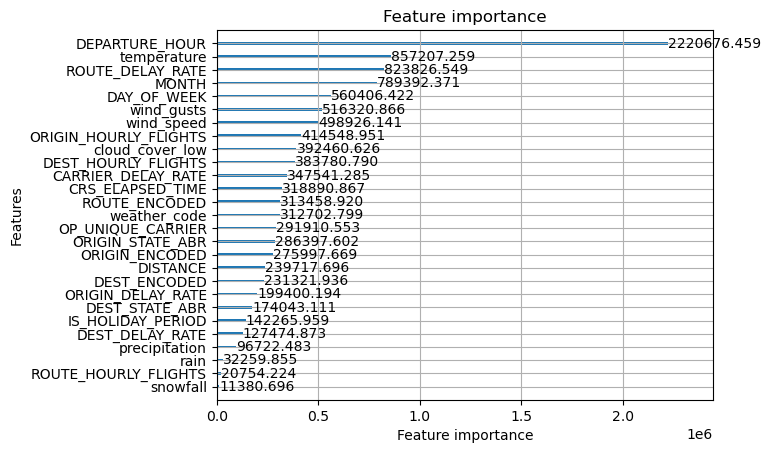

In [36]:
import lightgbm as lgbm
lgbm.plot_importance(final_model, max_num_features=27, importance_type='gain')

In [37]:
joblib.dump(final_model, '../models/best_model.pkl')

['../models/best_model.pkl']

In [38]:
joblib.dump(best_threshold, '../models/best_threshold.pkl')

['../models/best_threshold.pkl']